# Error Analysis

This notebook will be used to perform data alaysis of prediction errors. 
- Which attribute types had more errors/correct predictions?
    - Per model and template?

In [22]:
BEST_TEMPLATES = {
    "portuguese": {
               
        # ("gemini", "event triggers"): "ext_exp",
        ("gemini", "participants"): "cls_def_exp",
        ("qwen3_4b", "participants"): "cls_def_exp",
        ("gemma3_1b", "participants"): "ext_def_exp",
        # ("llama32_3b", "participants"): "cls_def",
        ("qwen25_14b", "participants"): "cls_exp",
        # ("gemini", "time expressions"): "ext_exp",
    },

    "english": {
        ("qwen3_4b", "participants"): "cls_def_exp",
        ("qwen25_14b", "participants"): "cls_exp",
        ("llama32_3b", "participants"): "cls_exp",
        ("gemma3_1b", "participants"): "ext_def_exp",
        ("gemini", "participants"): "cls_def_exp",
        
    }
}

In [23]:
BEST_TEMPLATES.get("portuguese", {})

{('gemini', 'participants'): 'cls_def_exp',
 ('qwen3_4b', 'participants'): 'cls_def_exp',
 ('gemma3_1b', 'participants'): 'ext_def_exp',
 ('qwen25_14b', 'participants'): 'cls_exp'}

In [24]:
def get_best_templates(BEST_TEMPLATES, language):
    return [(key[0], value) for key, value in BEST_TEMPLATES.get(language, {}).items()]

# Utils functions

In [85]:
import pandas as pd
from pathlib import Path

root = Path.cwd().resolve().parent if 'notebooks' in str(Path.cwd()) else Path.cwd().resolve()

DATA_FILES = {
    'english': root / 'results' / 'test' / 'english' / 'detailed_results_token_level.csv',
    'portuguese': root / 'results' / 'test' / 'portuguese' / 'detailed_results_token_level.csv',
}


def load_token_level_results(language: str) -> pd.DataFrame:
    path = DATA_FILES[language]
    df = pd.read_csv(path)
    df['result'] = df['result'].astype(str).str.strip().str.lower()
    df['result_type'] = df['result_type'].astype(str).str.strip().str.lower()
    df['word_category'] = df['word_category'].fillna('Sem categoria')
    return df


def compute_error_rates(df: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    # Global rate: FN / (TP + FN)
    global_counts = df['result'].value_counts().reindex(['tp', 'fn', 'fp']).fillna(0)
    global_fn = int(global_counts.get('fn', 0))
    global_tp = int(global_counts.get('tp', 0))
    global_rate = global_fn / (global_tp + global_fn) if (global_tp + global_fn) else 0.0

    # Per category: FN / (TP + FN)
    category_df = (
        df.groupby('word_category')
        .apply(lambda g: pd.Series({
            'fn': int((g['result'] == 'fn').sum()),
            'tp': int((g['result'] == 'tp').sum()),
            'total': int(len(g)),
        }))
        .reset_index()
    )
    category_df['error_rate'] = category_df['fn'] / (category_df['tp'] + category_df['fn'])
    category_df = category_df.sort_values(['error_rate', 'fn'], ascending=[False, False])

    # By result_type: Partial or Miss
    result_type_df = (
        df.groupby(['result_type', 'word_category'])
        .apply(lambda g: pd.Series({
            'fn': int((g['result'] == 'fn').sum()),
            'tp': int((g['result'] == 'tp').sum()),
            'total': int(len(g)),
        }))
        .reset_index()
    )
    result_type_df['error_rate'] = result_type_df['fn'] / (result_type_df['tp'] + result_type_df['fn'])
    result_type_df = result_type_df.sort_values(['result_type', 'error_rate', 'fn'], ascending=[True, False, False])

    return global_rate, category_df, result_type_df


def summarize_language(language: str):
    df = load_token_level_results(language)
    global_rate, category_df, result_type_df = compute_error_rates(df)

    print(f'=== {language.upper()} ===')
    print(f'Global token-level error rate (FN / TP+FN): {global_rate:.2%}')
    print('\nTop categories by lost tokens (FN rate):')
    print(category_df[['word_category', 'fn', 'tp', 'error_rate']].head(10).to_string(index=False))

    print('\nMost lost categories by result type:')
    for result_type in ['partial', 'miss']:
        subset = result_type_df[result_type_df['result_type'] == result_type]
        if subset.empty:
            continue
        best = subset.sort_values(['fn', 'error_rate'], ascending=[False, False]).head(1)
        print(f'{result_type}: {best.iloc[0]["word_category"]} (fn={int(best.iloc[0]["fn"])}, error_rate={best.iloc[0]["error_rate"]:.2%})')

    return {
        'language': language,
        'global_error_rate': global_rate,
        'category_rank': category_df,
        'result_type_rank': result_type_df,
    }

def analyze_result_types_by_entity(language: str):
    df = load_token_level_results(language)
    df = df.copy()

    # Normalize entity fields
    df['ann_entity_id'] = df['ann_entity_id'].fillna('')
    df['doc_id'] = df['doc_id'].fillna('')
    df['result_type'] = df['result_type'].astype(str).str.strip().str.lower()
    df['result'] = df['result'].astype(str).str.strip().str.lower()
    df['word_category'] = df['word_category'].fillna('Sem categoria')
    df['pct_tp_participant_level'] = df['pct_tp_participant_level'].fillna(0)

    # Returns a clean DataFrame with unique pairs of entity_id and result_type
    entity_result_dist = (
        df[['doc_id', 'ann_entity_id', 'result_type']]
        .drop_duplicates()
        .reset_index(drop=True)
    )
    print(f"Entity result distribution (unique pairs of doc_id, ann_entity_id, result_type) {entity_result_dist}")

    # Partial/Miss: which word_category loses most by FN
    result_type_and_category_raw = (
        df[['doc_id', 'ann_entity_id', 'word_category', 'result_type', 'result']]
    )
    
    result_type_and_category = (
        result_type_and_category_raw
        .groupby(['result_type', 'word_category'])
        .size()
        .reset_index(name='word_cat_count')
    )
    
    fn_by_result_type_and_category = (
        result_type_and_category_raw[result_type_and_category_raw['result'] == 'fn']
        .groupby(['result_type', 'word_category'])
        .size()
        .reset_index(name='fn_count')
    )

    pct_match_partial = (
        df[df['result_type'] == 'partial']
    )
    
    pct_match = (
        pct_match_partial[['doc_id', 'ann_entity_id', 'pct_tp_participant_level']]
        .drop_duplicates()
        .round({'pct_tp_participant_level': 1})
    )

    most_lost = (
        fn_by_result_type_and_category[fn_by_result_type_and_category['result_type'].isin(['partial', 'miss'])]
        .sort_values(['result_type', 'fn_count'], ascending=[True, False])
        .groupby('result_type')
        .first()
        .reset_index()
    )

    print(f'=== {language.upper()} - result type distribution by entity_id ===')
    print(entity_result_dist.head(20).to_string(index=False))
    print('\nDominant result type per entity_id:')
    # print(entity_dominant.head(20).to_string(index=False))
    print('\nMost lost word_category by FN for Partial/Miss:')
    print(most_lost.to_string(index=False))

    return {
        'entity_result_dist': entity_result_dist,
        'word_cat_general': result_type_and_category,
        'word_cat_lost': fn_by_result_type_and_category,
        'pct_match': pct_match,
    }



def build_global_top50_by_token(language: str, top_n: int = 50) -> pd.DataFrame:
    df = load_token_level_results(language)
    df['token'] = df['token'].astype(str).str.strip().str.lower()

    grouped = (
        df.groupby('token')
        .apply(lambda g: pd.Series({
            'fn': int((g['result'] == 'fn').sum()),
            'tp': int((g['result'] == 'tp').sum()),
            'total': int(len(g)),
        }))
        .reset_index()
    )
    grouped['error_rate'] = grouped['fn'] / (grouped['tp'] + grouped['fn'])

    # Load corpus token frequencies from the notebook folder
    freq_filename = 'word_freq_lusa_en.csv' if language == 'english' else 'word_freq_lusa_pt.csv'
    freq_path = root / 'notebooks' / freq_filename
    freq_df = pd.read_csv(freq_path)

    # Normalize column names and detect token/count columns
    freq_df.columns = [str(c).strip().lower() for c in freq_df.columns]
    token_col = next((c for c in freq_df.columns if c in {'token', 'word', 'term', 'lemma'}), freq_df.columns[0])
    count_col = next((c for c in freq_df.columns if c in {'count', 'freq', 'frequency', 'total'}), freq_df.columns[1] if len(freq_df.columns) > 1 else freq_df.columns[0])

    freq_df[token_col] = freq_df[token_col].astype(str).str.strip().str.lower()
    freq_counts = (
        freq_df[[token_col, count_col]]
        .drop_duplicates(subset=[token_col])
        .groupby(token_col)[count_col]
        .sum()
        .rename('token_total_count')
    )

    grouped = grouped.merge(
        freq_counts,
        left_on='token',
        right_index=True,
        how='left'
    )
    grouped['token_total_count'] = grouped['token_total_count'].fillna(0)

    # FN percentage over the token total frequency in the external corpus file
    grouped['fn_pct_over_token_total'] = (
        grouped['fn'] / grouped['token_total_count'].replace(0, pd.NA)
    ).fillna(0.0)

    # Representativeness of each token in the total FN universe
    total_fn = grouped['fn'].sum()
    grouped['fn_share_of_total_fns'] = grouped['fn'] / total_fn if total_fn else 0.0

    grouped = grouped.sort_values(
        ['fn_share_of_total_fns', 'fn', 'error_rate'],
        ascending=[False, False, False]
    ).head(top_n)

    grouped['language'] = language
    return grouped






## Result-type and entity-level analysis

Estas células respondem a:
- qual é a distribuição de ocorrências de result type (Partial, Miss, Exact) por entity_id;
- para Partial e Miss, qual é a word_category em que mais se perde por FN.

Entity result distribution (unique pairs of doc_id, ann_entity_id, result_type)        doc_id ann_entity_id result_type
0      lusa_1           T27       exact
1      lusa_1           T39     partial
2      lusa_1           T37       exact
3      lusa_1           T32     partial
4      lusa_1           T42     partial
...       ...           ...         ...
3592  lusa_98           T54        miss
3593  lusa_98           T68     partial
3594  lusa_98           T37       exact
3595  lusa_98           T47       exact
3596  lusa_98           T69     partial

[3597 rows x 3 columns]
=== PORTUGUESE - result type distribution by entity_id ===
 doc_id ann_entity_id result_type
 lusa_1           T27       exact
 lusa_1           T39     partial
 lusa_1           T37       exact
 lusa_1           T32     partial
 lusa_1           T42     partial
 lusa_1           T24       exact
 lusa_1           T25       exact
 lusa_1           T30       exact
 lusa_1           T36       exact
 lusa_1         

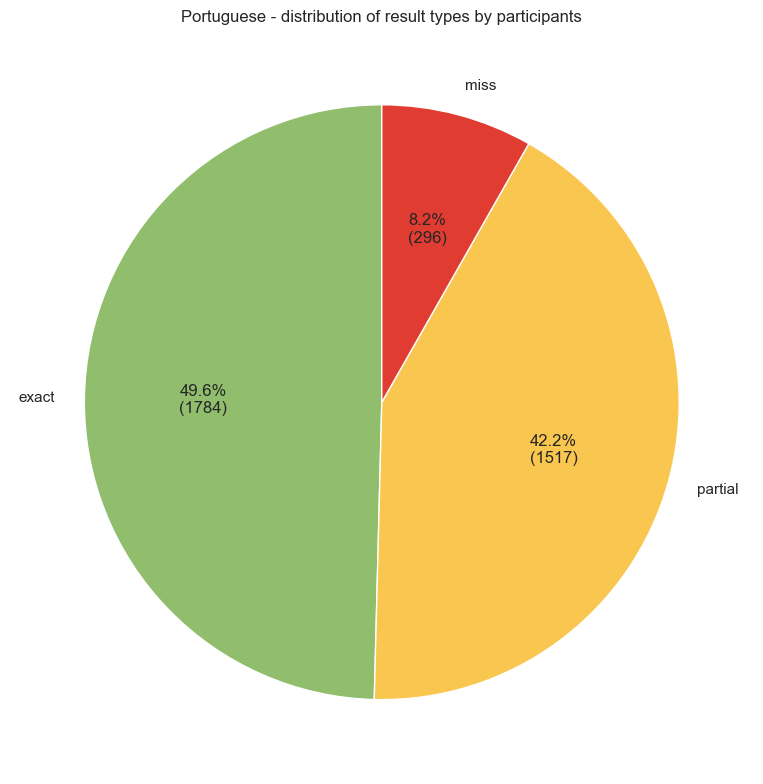

In [82]:
import matplotlib.pyplot as plt
import seaborn as sns

for language in ['portuguese']:
    summary = analyze_result_types_by_entity(language)
    dist = summary['entity_result_dist'].copy()
    if dist.empty:
        continue

    # 1. Aggregate the data and enforce your specific order
    counts = dist['result_type'].value_counts().reindex(['exact', 'partial', 'miss'], fill_value=0)

    # 2. Plot the pie chart
    plt.figure(figsize=(8, 8)) # A square figure size prevents the pie from looking oval
    plt.pie(
        counts, 
        labels=counts.index, 
        # The lambda function takes the percentage (pct) and formats it alongside the absolute count
        autopct=lambda pct: f"{pct:.1f}%\n({int(round(pct * counts.sum() / 100))})",
        startangle=90,     
        colors=["#90BE6D", "#F9C74F", "#E03C31"] 
    )

    plt.title(f'{language.title()} - distribution of result types by participants')
    plt.tight_layout()
    plt.show()


## Token-level error analysis

Estas células calculam:
- a taxa global de erro por token level, usando $FN / (TP + FN)$;
- a taxa de erro por categoria lexical, como $FN / (TP + FN)$;
- a categoria mais perdida para os resultados do tipo Partial e Miss, com base nos FN.

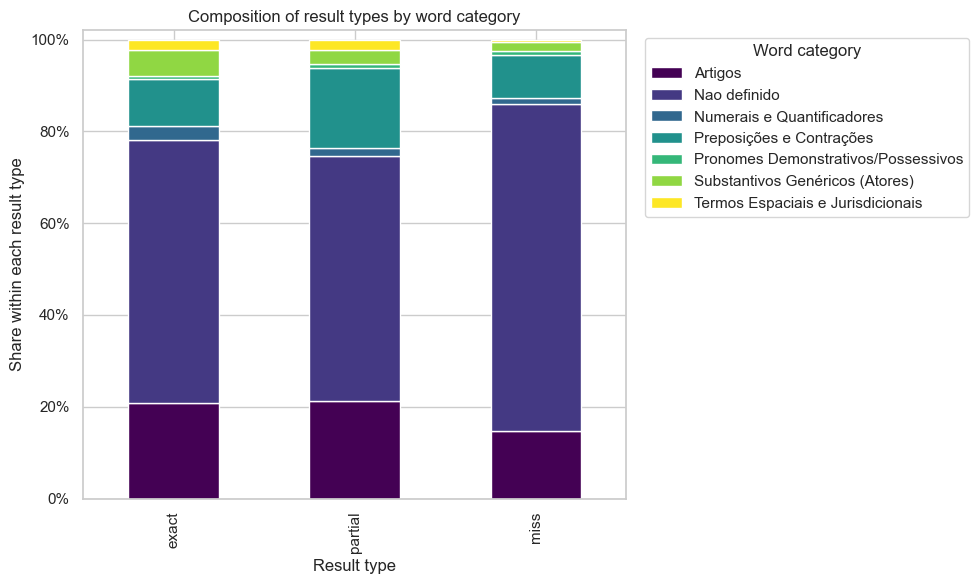

word_category,Artigos,Nao definido,Numerais e Quantificadores,Preposições e Contrações,Pronomes Demonstrativos/Possessivos,Substantivos Genéricos (Atores),Termos Espaciais e Jurisdicionais
result_type,,,,,,,
exact,4752,13123,709,2330,131,1299,532
partial,6207,15673,492,5088,259,920,661
miss,1055,5063,96,666,64,141,38


In [ ]:
from matplotlib.ticker import PercentFormatter

# Use the composition table already produced by analyze_result_types_by_entity()
word_cat_general = summary['word_cat_general'].copy()

# Matrix: rows = result_type, cols = word_category, values = counts
stacked_counts = (
    word_cat_general.pivot_table(
        index='result_type',
        columns='word_category',
        values='word_cat_count',
        aggfunc='sum',
    )
    .reindex(['exact', 'partial', 'miss'], fill_value=0)
    .fillna(0)
)

# Convert to composition within each result type
stacked_pct = stacked_counts.div(stacked_counts.sum(axis=1), axis=0).fillna(0)

# Plot stacked bar: composition of each result type by word category
fig, ax = plt.subplots(figsize=(10, 6))
stacked_pct.plot(
    kind='bar',
    stacked=True,
    ax=ax,
    colormap='viridis',
)

ax.set_title('Composition of result types by word category')
ax.set_xlabel('Result type')
ax.set_ylabel('Share within each result type')
ax.set_ylim(0, 1.02)
ax.yaxis.set_major_formatter(PercentFormatter(xmax=1))
ax.legend(title='Word category', bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()
plt.show()

# Optional: inspect the raw count matrix
display(stacked_counts)

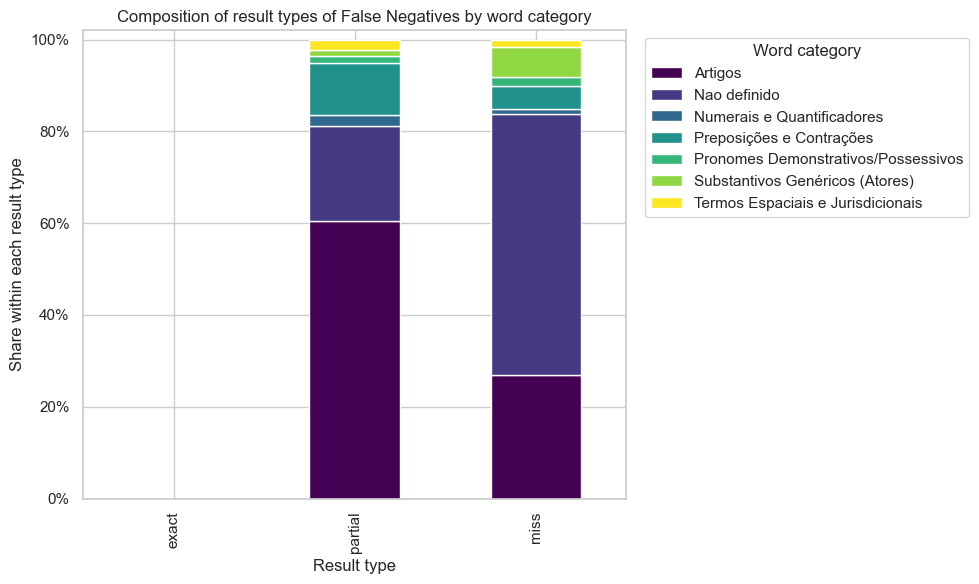

word_category,Artigos,Nao definido,Numerais e Quantificadores,Preposições e Contrações,Pronomes Demonstrativos/Possessivos,Substantivos Genéricos (Atores),Termos Espaciais e Jurisdicionais
result_type,,,,,,,
exact,0,0,0,0,0,0,0
partial,4139,1413,174,779,96,93,154
miss,260,547,10,48,20,63,15


In [74]:
from matplotlib.ticker import PercentFormatter

# Use the composition table already produced by analyze_result_types_by_entity()
word_cat_lost = summary['word_cat_lost'].copy()

# Matrix: rows = result_type, cols = word_category, values = counts
stacked_counts = (
    word_cat_lost.pivot_table(
        index='result_type',
        columns='word_category',
        values='fn_count',
        aggfunc='sum',
    )
    .reindex(['exact', 'partial', 'miss'], fill_value=0)
    .fillna(0)
)

# Convert to composition within each result type
stacked_pct = stacked_counts.div(stacked_counts.sum(axis=1), axis=0).fillna(0)

# Plot stacked bar: composition of each result type by word category
fig, ax = plt.subplots(figsize=(10, 6))
stacked_pct.plot(
    kind='bar',
    stacked=True,
    ax=ax,
    colormap='viridis',
)

ax.set_title('Composition of result types of False Negatives by word category')
ax.set_xlabel('Result type')
ax.set_ylabel('Share within each result type')
ax.set_ylim(0, 1.02)
ax.yaxis.set_major_formatter(PercentFormatter(xmax=1))
ax.legend(title='Word category', bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()
plt.show()

# Optional: inspect the raw count matrix
display(stacked_counts)

In [ ]:
results = {lang: summarize_language(lang) for lang in ['portuguese']}

for lang, summary in results.items():
    print(f'\n=== {lang} summary ===')
    print(summary['category_rank'][['word_category', 'fn', 'tp', 'error_rate']].head(15).to_string(index=False))


=== PORTUGUESE ===
Global token-level error rate (FN / TP+FN): 16.68%

Top categories by lost tokens (FN rate):
                      word_category   fn    tp  error_rate
Pronomes Demonstrativos/Possessivos  116   135    0.462151
                            Artigos 4399  5699    0.435631
         Numerais e Quantificadores  184   991    0.156596
           Preposições e Contrações  827  4643    0.151188
  Termos Espaciais e Jurisdicionais  169  1005    0.143952
    Substantivos Genéricos (Atores)  156  1863    0.077266
                       Nao definido 1960 24685    0.073560

Most lost categories by result type:
partial: Artigos (fn=4139, error_rate=81.38%)
miss: Nao definido (fn=547, error_rate=100.00%)

=== portuguese summary ===
                      word_category   fn    tp  error_rate
Pronomes Demonstrativos/Possessivos  116   135    0.462151
                            Artigos 4399  5699    0.435631
         Numerais e Quantificadores  184   991    0.156596
           Preposiçõ

C:\Users\davib\AppData\Local\Temp\ipykernel_37100\3516938756.py:30: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df.groupby('word_category')
C:\Users\davib\AppData\Local\Temp\ipykernel_37100\3516938756.py:43: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df.groupby(['result_type', 'word_category'])


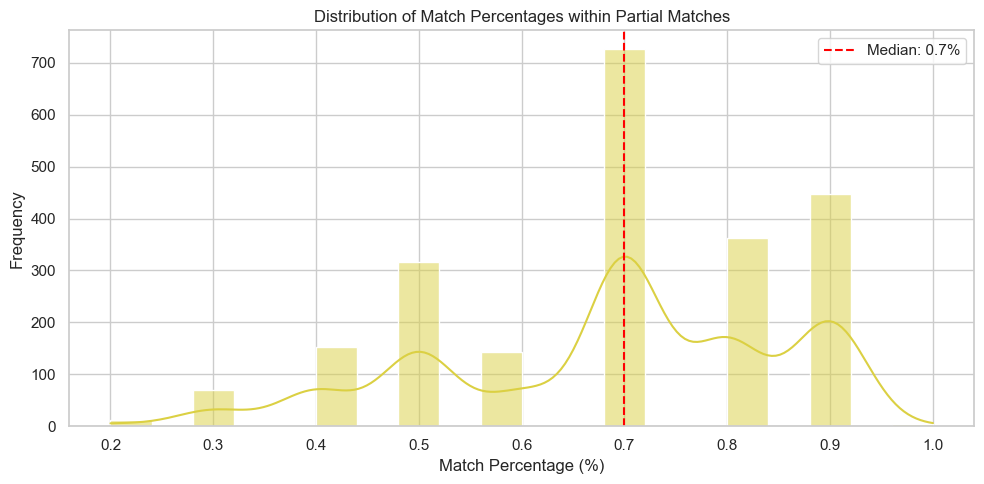

In [83]:
import seaborn as sns
import matplotlib.pyplot as plt

partial_df = summary['pct_match'].copy()

# Assuming you have a dataframe 'partial_df' with a column 'match_percentage' (0-100)
plt.figure(figsize=(10, 5))
sns.histplot(data=partial_df, x='pct_tp_participant_level', bins=20, kde=True, color='#dbd043')

plt.title('Distribution of Match Percentages within Partial Matches')
plt.xlabel('Match Percentage (%)')
plt.ylabel('Frequency')
plt.axvline(partial_df['pct_tp_participant_level'].median(), color='red', linestyle='--', label=f"Median: {partial_df['pct_tp_participant_level'].median():.1f}%")
plt.legend()
plt.tight_layout()
plt.show()

C:\Users\davib\AppData\Local\Temp\ipykernel_37100\170387888.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=category_rank, x='error_rate', y='word_category', palette='viridis')


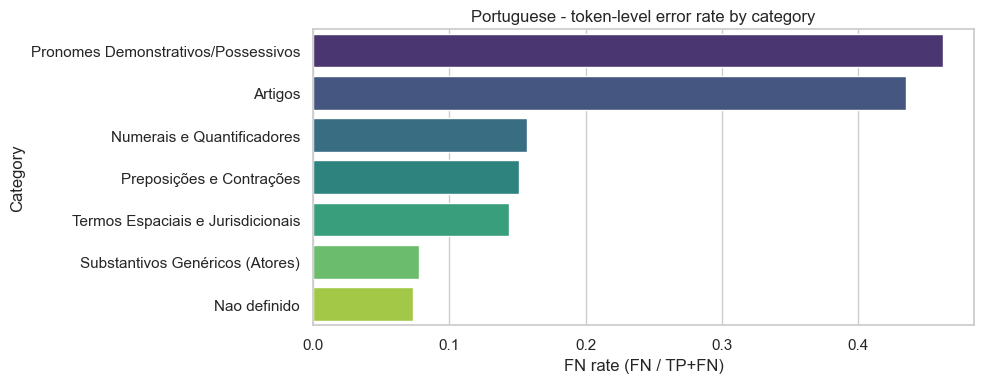

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')

for lang, summary in results.items():
    category_rank = summary['category_rank'].head(10).copy()
    plt.figure(figsize=(10, 4))
    sns.barplot(data=category_rank, x='error_rate', y='word_category', palette='viridis')
    plt.title(f'{lang.title()} - token-level error rate by category')
    plt.xlabel('FN rate (FN / TP+FN)')
    plt.ylabel('Category')
    plt.tight_layout()
    plt.show()


## Global top-50 token-loss ranking

Esta secção responde à questão:
- qual é o rank top 50, em percentagem, dos tokens perdidos globalmente, medido como $FN / (TP + FN)$.

In [ ]:
for language in ['portuguese']:
    top50_tokens = build_global_top50_by_token(language, top_n=1000)
    print(f'=== {language.upper()} top-50 token-loss ranking ===')
    print(top50_tokens[['token', 'fn', 'tp', 'error_rate']].to_string(index=False))
    print()


=== PORTUGUESE top-50 token-loss ranking ===
            token   fn   tp  error_rate
              mal   15    0    1.000000
           aquele   12    0    1.000000
              aos   10    0    1.000000
       estampilha    8    0    1.000000
           fiscal    8    0    1.000000
               ma    8    0    1.000000
            olhão    8    0    1.000000
              que    7    0    1.000000
               62    6    0    1.000000
              num    6    0    1.000000
               72    5    0    1.000000
            lagoa    5    0    1.000000
             numa    5    0    1.000000
           medida    4    0    1.000000
    personalidade    4    0    1.000000
           relevo    4    0    1.000000
             dela    2    0    1.000000
             suas    2    0    1.000000
        austríaca    1    0    1.000000
        macedónia    1    0    1.000000
          maneira    1    0    1.000000
               me    1    0    1.000000
          notícia    1    0    1.00

C:\Users\davib\AppData\Local\Temp\ipykernel_37100\2689440761.py:6: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df.groupby('token')


C:\Users\davib\AppData\Local\Temp\ipykernel_37100\2689440761.py:6: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df.groupby('token')
C:\Users\davib\AppData\Local\Temp\ipykernel_37100\3058988606.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top50_tokens, x='error_rate', y='token', palette='rocket')


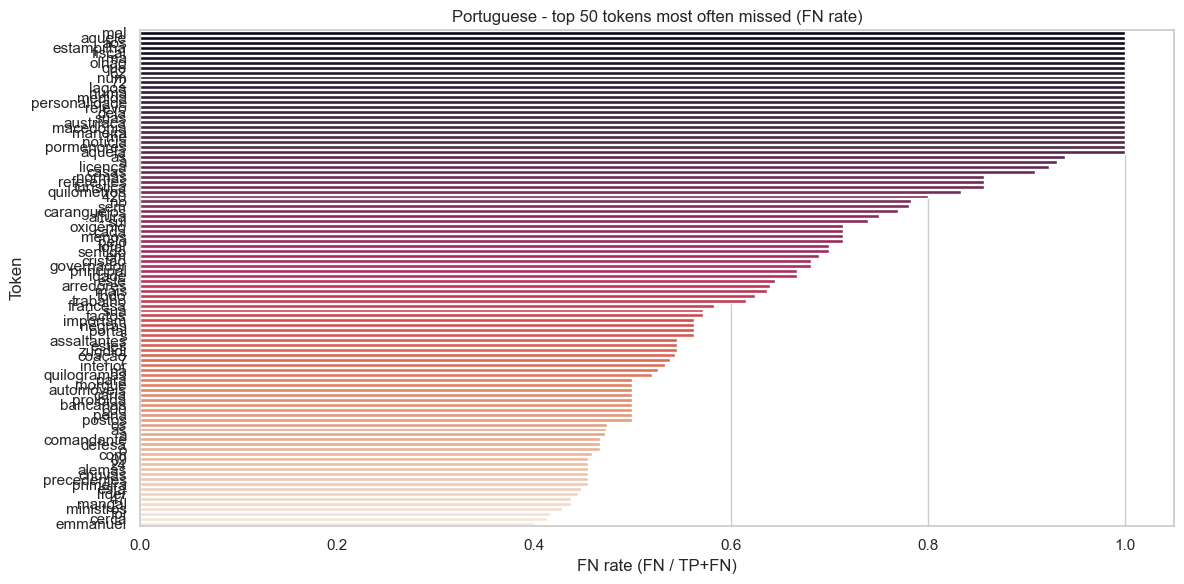

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

for language in ['portuguese']:
    top50_tokens = build_global_top50_by_token(language, top_n=100)
    plt.figure(figsize=(12, 6))
    sns.barplot(data=top50_tokens, x='error_rate', y='token', palette='rocket')
    plt.title(f'{language.title()} - top 50 tokens most often missed (FN rate)')
    plt.xlabel('FN rate (FN / TP+FN)')
    plt.ylabel('Token')
    plt.tight_layout()
    plt.show()


In [87]:
grouped = build_global_top50_by_token('portuguese', top_n=50)
grouped

C:\Users\davib\AppData\Local\Temp\ipykernel_37100\2367765146.py:159: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df.groupby('token')
C:\Users\davib\AppData\Local\Temp\ipykernel_37100\2367765146.py:197: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  grouped['fn_pct_over_token_total'] = (


,token,fn,tp,total,error_rate,token_total_count,fn_pct_over_token_total,fn_share_of_total_fns,language
1441,o,1734,1982,4361,0.466631,517.0,3.353965,0.221995,portuguese
114,a,1521,1701,3745,0.472067,674.0,2.256677,0.194725,portuguese
1477,os,445,493,1038,0.474414,116.0,3.836207,0.056971,portuguese
621,de,370,3363,4550,0.099116,1435.0,0.257840,0.047369,portuguese
2008,um,350,810,1503,0.301724,252.0,1.388889,0.044809,portuguese
252,as,211,235,560,0.473094,74.0,2.851351,0.027013,portuguese
2009,uma,137,465,793,0.227575,180.0,0.761111,0.017539,portuguese
755,em,102,46,183,0.689189,331.0,0.308157,0.013059,portuguese
213,anos,86,503,629,0.146010,137.0,0.627737,0.011010,portuguese
2101,à,81,6,109,0.931034,113.0,0.716814,0.010370,portuguese
